## importando as bibliotecas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb



importar base direto do google planilhas

In [ ]:
from google.colab import auth
import gspread
from google.auth import default

auth.authenticate_user()

url = "https://docs.google.com/spreadsheets/d/1XGXz2MQOiKGT8Hx40q8PElHdUSTugArkKWZm0H1Nssc/export?format=csv&gid=0#gid=0"

df = pd.read_csv(url)

df.head()

,data,linha,turno,produtos_ok,produtos_defeituosos,tipo_defeito_principal,horas_trabalhadas,meta_diaria
0,2026-07-01,L1,A,333,10,Dimensional,7.6,320
1,2026-07-01,L1,B,324,13,Solda,7.9,320
2,2026-07-01,L1,C,307,15,Dimensional,7.5,320
3,2026-07-01,L2,A,296,23,Solda,7.8,320
4,2026-07-01,L2,B,265,23,Riscos,7.6,320


primeiras análises da base

In [ ]:
df['linha'].value_counts()
df.groupby('produtos_ok')['produtos_ok'].mean()


,produtos_ok
produtos_ok,
215,215.0
225,225.0
227,227.0
233,233.0
238,238.0
...,...
378,378.0
379,379.0
384,384.0


## linhas e colunas na tabela

In [ ]:
#linhas na tabela
print('formato da tabela' , df.shape)
print(f'{df.shape[0]} linhas e {df.shape[1]} colunas')

formato da tabela (270, 8)
270 linhas e 8 colunas


In [ ]:
#tipos de colunas
df.dtypes

,0
data,object
linha,object
turno,object
produtos_ok,int64
produtos_defeituosos,int64
tipo_defeito_principal,object
horas_trabalhadas,float64
meta_diaria,int64


In [ ]:
#existem dados em branco
df.isnull().sum()

,0
data,0
linha,0
turno,0
produtos_ok,0
produtos_defeituosos,0
tipo_defeito_principal,0
horas_trabalhadas,0
meta_diaria,0


In [ ]:
#linhas duplicadas
print('linhas duplicadas' , df.duplicated().sum())

linhas duplicadas 0


## convertendo valores de data

In [ ]:
#convertendo valores de data de texto para o tipo datetime

df['data'] = pd.to_datetime(df['data'])

df.dtypes

,0
data,datetime64[ns]
linha,object
turno,object
produtos_ok,int64
produtos_defeituosos,int64
tipo_defeito_principal,object
horas_trabalhadas,float64
meta_diaria,int64


In [ ]:
#criar novas colunas

df['total_produzido'] = df['produtos_defeituosos'] + df['produtos_ok']

df['taxa_refugo_pct'] = (df['produtos_defeituosos'] / df['total_produzido']) * 100

df['atingiu_meta'] = df['produtos_ok'] >= df['meta_diaria']

#arrendondando taxa refugo

df['taxa_refugo_pct'] = df['taxa_refugo_pct'].round(2)

#ver resultado
df

,data,linha,turno,produtos_ok,produtos_defeituosos,tipo_defeito_principal,horas_trabalhadas,meta_diaria,total_produzido,taxa_refugo_pct,atingiu_meta
0,2026-07-01,L1,A,333,10,Dimensional,7.6,320,343,2.92,True
1,2026-07-01,L1,B,324,13,Solda,7.9,320,337,3.86,True
2,2026-07-01,L1,C,307,15,Dimensional,7.5,320,322,4.66,False
3,2026-07-01,L2,A,296,23,Solda,7.8,320,319,7.21,False
4,2026-07-01,L2,B,265,23,Riscos,7.6,320,288,7.99,False
...,...,...,...,...,...,...,...,...,...,...,...
265,2026-07-30,L2,B,297,19,Acabamento,7.5,320,316,6.01,False
266,2026-07-30,L2,C,260,26,Pintura,7.9,320,286,9.09,False
267,2026-07-30,L3,A,365,14,Riscos,7.8,320,379,3.69,True
268,2026-07-30,L3,B,352,15,Solda,8.0,320,367,4.09,True


## estatística descritiva

em média, quantas peças são produzidas por turno?

qual o 'meio' da distribuição?

os valores variam muito ou pouco?

In [ ]:
df.describe()

,data,produtos_ok,produtos_defeituosos,horas_trabalhadas,meta_diaria,total_produzido,taxa_refugo_pct
count,270,270.000000,270.000000,270.000000,270.0,270.000000,270.000000
mean,2026-07-15 12:00:00,309.696296,16.122222,7.748889,320.0,325.818519,5.080222
min,2026-07-01 00:00:00,215.000000,5.000000,7.500000,320.0,236.000000,1.470000
25%,2026-07-08 00:00:00,285.000000,12.000000,7.600000,320.0,303.000000,3.530000
50%,2026-07-15 12:00:00,314.000000,15.000000,7.800000,320.0,327.000000,4.695000
75%,2026-07-23 00:00:00,334.500000,20.000000,7.900000,320.0,346.000000,6.430000
max,2026-07-30 00:00:00,387.000000,31.000000,8.000000,320.0,405.000000,10.730000
std,NaN,34.882761,5.520818,0.145243,0.0,31.962112,2.077853


In [ ]:
#analise da coluna produto_ok

pecas_ok = df['produtos_ok']

#media

media = pecas_ok.sum() / len(pecas_ok)
print(f'media calculada: {media:.2f}')
print(f'media com .mean(): {pecas_ok.mean():.2f}')

#mediana

pecas_ordenadas = pecas_ok.sort_values().reset_index(drop=True)
n = len(pecas_ordenadas)

mediana_manual = (pecas_ordenadas[n//2 - 1] + pecas_ordenadas[n//2]) / 2
print(f'mediana calculada manual {mediana_manual}')
print(f'mediana com .median() {pecas_ok.median()}')

#moda

print('moda de produtos_ok:')
print(pecas_ok.mode())

media calculada: 309.70
media com .mean(): 309.70
mediana calculada manual 314.0
mediana com .median() 314.0
moda de produtos_ok:
0    319
Name: produtos_ok, dtype: int64


In [ ]:
#media x mediana
#utilizando medidas de dispersão

print(f'amplitude (max-min): {pecas_ok.max() - pecas_ok.min()}')
print(f'variancia: {pecas_ok.var():.2f}')
print(f'desvio padrão: {pecas_ok.std():.2f}')

amplitude (max-min): 172
variancia: 1216.81
desvio padrão: 34.88


## comparação com groupby()

In [ ]:
df.groupby('linha')['produtos_ok'].mean().round(2)

df.groupby('turno')['produtos_ok'].mean().round(2)

#varios indicadores ao mesmo tempo, por linha
df.groupby('linha').agg({
    'produtos_ok' : 'mean',
    'taxa_refugo_pct' : 'mean',
    'atingiu_meta' : 'mean'
}).round(2)

,produtos_ok,taxa_refugo_pct,atingiu_meta
linha,,,
L1,315.22,3.57,0.42
L2,274.17,7.39,0.01
L3,339.70,4.28,0.80


In [ ]:
#contagem de defeito

contagem_defeito = df['produtos_defeituosos'].value_counts()
contagem_defeito

,count
produtos_defeituosos,
15,28
16,22
13,19
19,18
12,18
11,16
10,14
23,14
9,12


In [ ]:
#percentual dos produtos com defeito

df['tipo_defeito_principal'].value_counts(normalize=True).mul(100).round(2)

,proportion
tipo_defeito_principal,
Pintura,21.48
Acabamento,20.37
Solda,20.37
Dimensional,19.63
Riscos,18.15


histograma


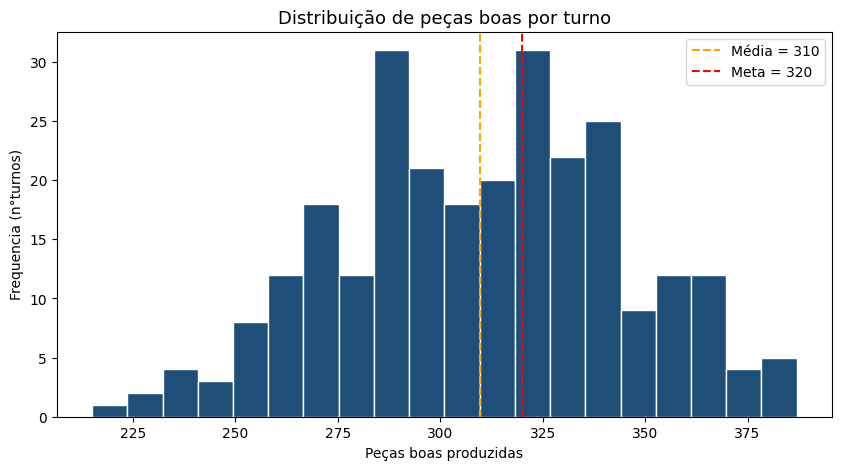

In [ ]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10,5))
plt.hist(df['produtos_ok'], bins=20, color="#1F4E79", edgecolor="white")
plt.title("Distribuição de peças boas por turno", fontsize=13)
plt.xlabel("Peças boas produzidas")
plt.ylabel("Frequencia (n°turnos)")
plt.axvline(df['produtos_ok'].mean(), color="orange",linestyle="--", label=f"Média = {df['produtos_ok'].mean():.0f}")
plt.axvline(320, color="red", linestyle="--", label="Meta = 320")
plt.legend()
plt.show()

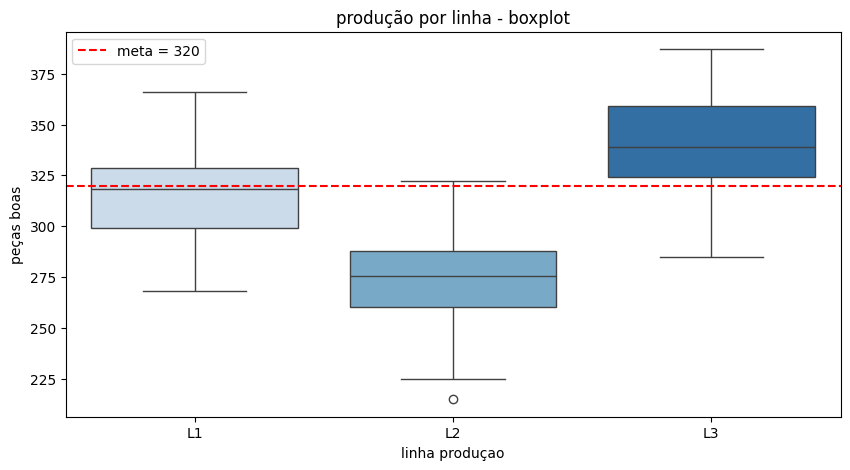

In [ ]:
plt.figure(figsize=(10,5))
sb.boxplot(data=df, x='linha', y='produtos_ok', hue ='linha' , palette = 'Blues', legend=False)
plt.axhline(320, color='red' , linestyle = '--' , label = 'meta = 320')
plt.title('produção por linha - boxplot')
plt.xlabel("linha produçao")
plt.ylabel("peças boas")
plt.legend()
plt.show()

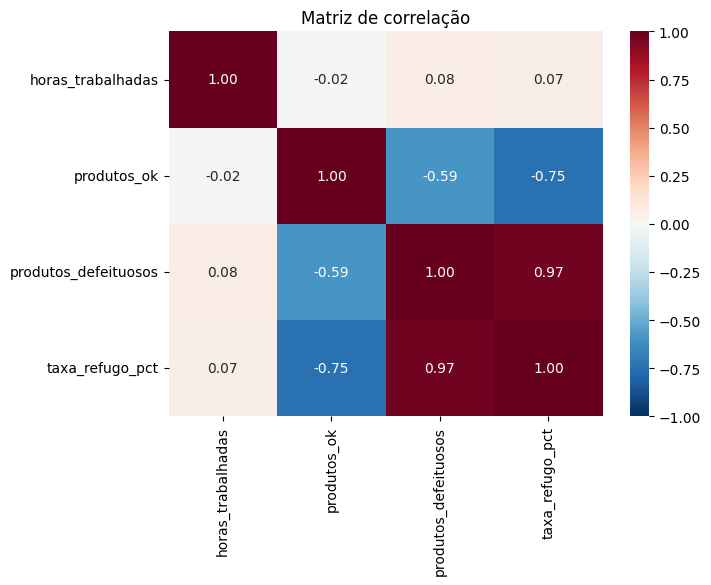

In [ ]:
correlacao = df[['horas_trabalhadas', 'produtos_ok', "produtos_defeituosos", "taxa_refugo_pct"]].corr()

# Matriz de Calor
plt.figure(figsize=(7, 5))
sb.heatmap(correlacao, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.show()

desafio1

> qual foi o da com a maior produção

